## Setup

Run this notebook from a local clone of the [svm-gmu](https://github.com/SushrutGaikwad/svm-gmu) repository. From the repo root, install the project and launch Jupyter with [uv](https://docs.astral.sh/uv/):

```bash
uv sync
uv run jupyter lab
```

The next cell puts the repo's `src/` and `experiments/` folders on the import path, so `svm_gmu` and the shared `_common` helper import from your local clone. Rendering uses your local LaTeX (`pdflatex`).

In [1]:
import sys
from pathlib import Path


def _add_repo_to_path():
    """Put the repo's experiments/ and src/ folders on sys.path.

    Locates the svm-gmu repository by searching upward from the working
    directory, so the notebook runs from any local clone regardless of where
    Jupyter was started.
    """
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (base / "experiments" / "_common.py").exists():
            exp, src = base / "experiments", base / "src"
        elif (base / "_common.py").exists():
            exp, src = base, base.parent / "src"
        else:
            continue
        for path in (str(exp), str(src)):
            if path not in sys.path:
                sys.path.insert(0, path)
        return
    raise RuntimeError(
        "Could not find the svm-gmu repository. Run this notebook from a local "
        "clone (for example, `uv run jupyter lab` from the repo root)."
    )


_add_repo_to_path()

import _common as C

# Experiment 1: Fitting SVM-GMU on the `close_separable` Dataset

This notebook fits SVM-GMU on the six-point banana/crescent `close_separable` dataset and a standard linear SVM on the same observed points, then regenerates the three Experiment 1 figures used in the report. Each figure is saved as a `.pgf` into the report's `graphics/` directory with the exact filename the report `\input`s, rendered with the LaTeX serif font so it matches the document.

## 1. Imports and LaTeX rendering

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty, plot_boundary, plot_boundary_comparison

# Render every figure with the report's LaTeX serif font (pdflatex + lmodern),
# for both the inline preview and the saved .pgf.
C.configure_pgf()

GRAPHICS_DIR = C.GRAPHICS_DIR
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

X, y, SU = C.X, C.y, C.SAMPLE_UNCERTAINTY

## 2. Fit SVM-GMU and the standard SVM

Both use the same regularization and seed; SVM-GMU additionally receives the per-sample GMM `sample_uncertainty`.

In [3]:
# SVM-GMU sees the full mixture uncertainty; the standard SVM sees only the
# observed points (sample_uncertainty omitted). The standard SVM gets more
# iterations because the hard hinge has flat regions that slow SGD.
model_gmu = SvmGmu(lam=C.LAM, max_iter=1000, batch_size=len(X), random_state=C.SVM_SEED)
model_gmu.fit(X, y, sample_uncertainty=SU)

model_svm = SvmGmu(lam=C.LAM, max_iter=5000, batch_size=len(X), random_state=C.SVM_SEED)
model_svm.fit(X, y)

print(f"SVM-GMU:      w = {model_gmu.coef_},  b = {model_gmu.intercept_:.4f}")
print(f"standard SVM: w = {model_svm.coef_},  b = {model_svm.intercept_:.4f}")

SVM-GMU:      w = [-1.25267325  1.25886418],  b = -0.9470
standard SVM: w = [-0.81062493  0.25751718],  b = -0.4547


## 3. Dataset uncertainty contours

Saved as `dataset_gmm_uncertainty_contours.pgf`.

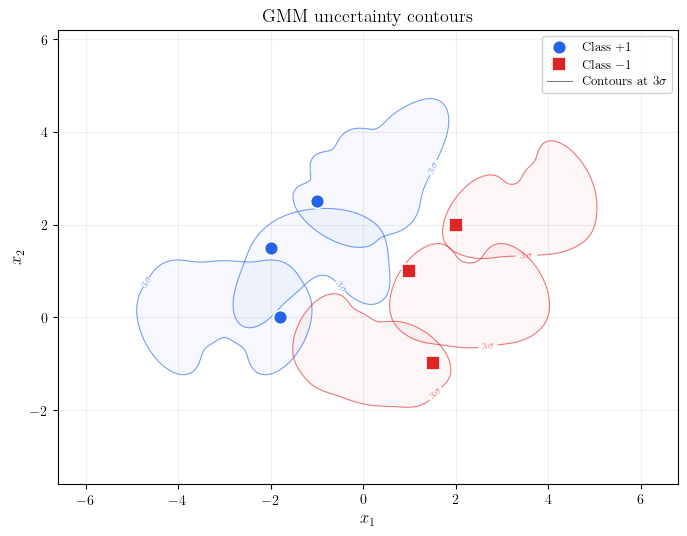

In [4]:
# Figure 1: the six per-sample GMM uncertainty contours (3-sigma), no model.
fig, ax = plot_uncertainty(
    X, y, SU, sigmas=(3,), figsize=(8, 7),
    title="GMM uncertainty contours",
)
fig.savefig(GRAPHICS_DIR / "dataset_gmm_uncertainty_contours.pgf",
            backend="pgf", bbox_inches="tight")
plt.show()

## 4. SVM-GMU decision boundary

Saved as `svm-gmu_decision_boundary.pgf`.

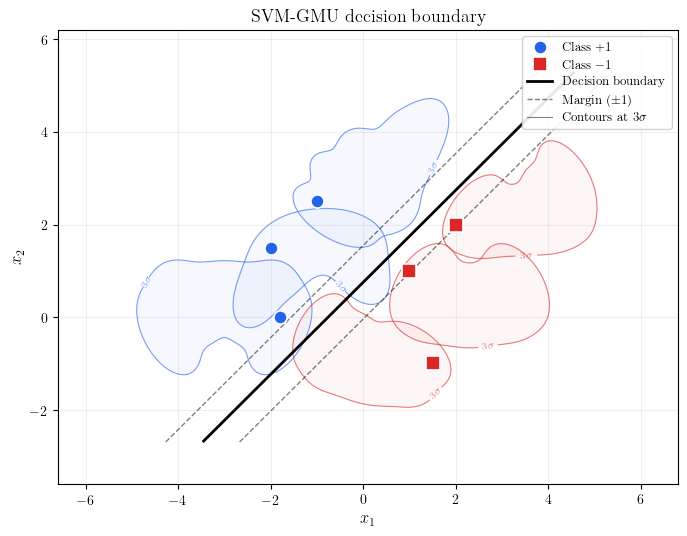

In [5]:
# Figure 2: the learned SVM-GMU decision boundary and margins over the contours.
fig, ax = plot_boundary(
    X, y, SU, model_gmu, sigmas=(3,), figsize=(8, 7),
    title="SVM-GMU decision boundary",
)
fig.savefig(GRAPHICS_DIR / "svm-gmu_decision_boundary.pgf",
            backend="pgf", bbox_inches="tight")
plt.show()

## 5. SVM-GMU vs. standard SVM

Saved as `comparison.pgf`.

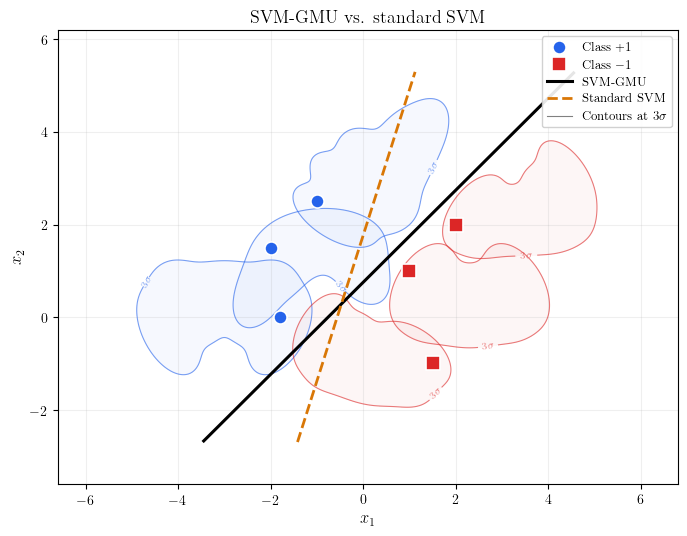

In [6]:
# Figure 3: SVM-GMU (solid black) vs the standard SVM (dashed orange).
fig, ax = plot_boundary_comparison(
    X, y, SU, model_gmu, model_svm, sigmas=(3,), figsize=(8, 7),
    title="SVM-GMU vs. standard SVM",
)
fig.savefig(GRAPHICS_DIR / "comparison.pgf", backend="pgf", bbox_inches="tight")
plt.show()